In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import math
import glob

import FileHelper

In [2]:
fileNames = glob.glob('/Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus*.root')
trainVarFile = '/Users/isobel/Desktop/DUNE/Ivysaurus/files/trainVarArrays.npz'
print(fileNames)

['/Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus_nu_0.root', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus_nue_0.root']


In [3]:
nClasses = 6

In [4]:
displacement, dca, trackStubLength, nuVertexAvSeparation, nuVertexChargeAsymmetry, initialGapSize, largestGapSize, pathwayLength, pathwayScatteringAngle2D, showerNHits, foundHitRatio, scatterAngle, openingAngle, nuVertexEnergyAsymmetry, nuVertexEnergyWeightedMeanRadialDistance, showerStartEnergyAsymmetry, showerStartMoliereRadius, nAmbiguousViews, unaccountedEnergy, particlePDG = FileHelper.readShowerVars(fileNames)

Reading tree:  /Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus_nu_0.root , This may take a while...
Reading tree:  /Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus_nue_0.root , This may take a while...


In [5]:
particleColors = ('b', 'g', 'k', 'r', 'tab:orange', 'tab:gray')

# muons = 0, protons = 1, pions = 2, electrons = 3, photons = 4, other = 5
nMuons = np.count_nonzero(particlePDG == 0)    
nProtons = np.count_nonzero(particlePDG == 1)  
nPions = np.count_nonzero(particlePDG == 2)  
nElectrons = np.count_nonzero(particlePDG == 3)  
nPhotons = np.count_nonzero(particlePDG == 4)  
nOther = np.count_nonzero(particlePDG == 5) 

print('nMuons:', nMuons)
print('nProtons: ', nProtons)
print('nPions: ', nPions)
print('nElectrons: ', nElectrons)
print('nPhotons: ', nPhotons)
print('nOther: ', nOther)

nParticles = [nMuons, nProtons, nPions, nElectrons, nPhotons, nOther]

nMuons: 38118
nProtons:  69470
nPions:  55640
nElectrons:  36936
nPhotons:  61735
nOther:  0


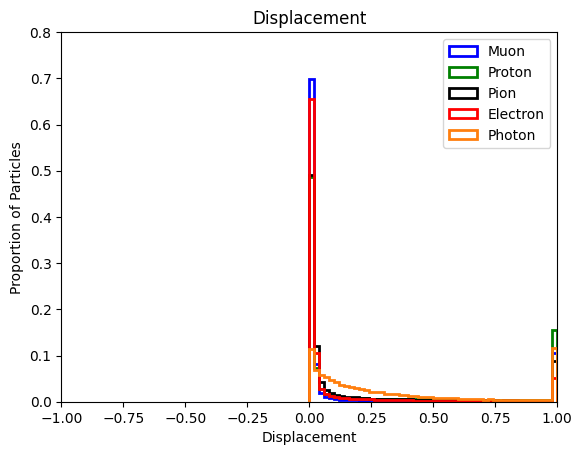

In [6]:
# Plot the displacement

displacementMin = -150
displacementMax = 150
    
for i in range(5) :

    thisDisplacement = displacement[particlePDG == i]
    
    thisDisplacement[thisDisplacement > displacementMax] = displacementMax
    thisDisplacement[thisDisplacement < 0] = displacementMin
    thisDisplacement = thisDisplacement / displacementMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisDisplacement, bins=50, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-1.0, 1.0])
plt.ylim([0.0, 0.8])
plt.xlabel('Displacement')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('Displacement')

plt.show()

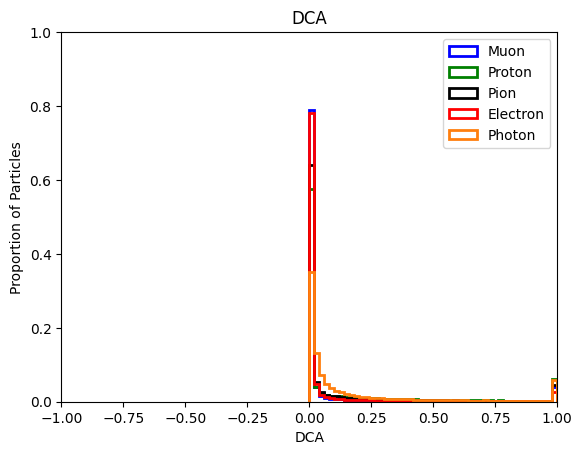

In [7]:
# Plot the dca

dcaMin = -150
dcaMax = 150
    
for i in range(5) :

    thisDCA = dca[particlePDG == i]
    
    thisDCA[thisDCA > dcaMax] = dcaMax
    thisDCA[thisDCA < 0] = dcaMin
    thisDCA = thisDCA / dcaMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisDCA, bins=50, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-1.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('DCA')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('DCA')

plt.show()


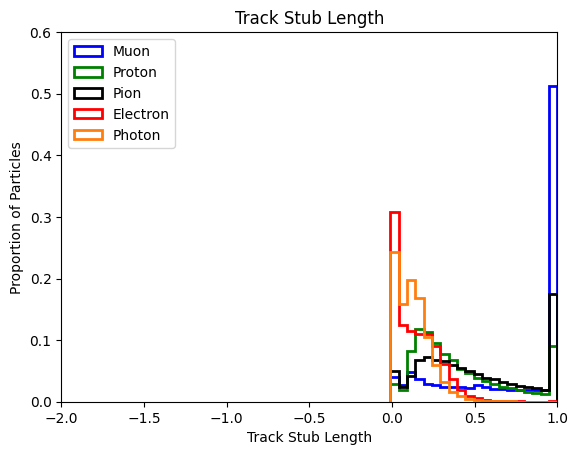

In [8]:
# Plot the track stub length

trackStubLengthMin = -100
trackStubLengthMax = 100
    
for i in range(5) :

    thisTrackStubLength = trackStubLength[particlePDG == i]
    
    thisTrackStubLength[thisTrackStubLength > trackStubLengthMax] = trackStubLengthMax
    thisTrackStubLength[thisTrackStubLength < trackStubLengthMin] = trackStubLengthMin
    thisTrackStubLength = thisTrackStubLength / trackStubLengthMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisTrackStubLength, bins=20, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 1.0])
plt.ylim([0.0, 0.6])
plt.xlabel('Track Stub Length')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('Track Stub Length')

plt.show()

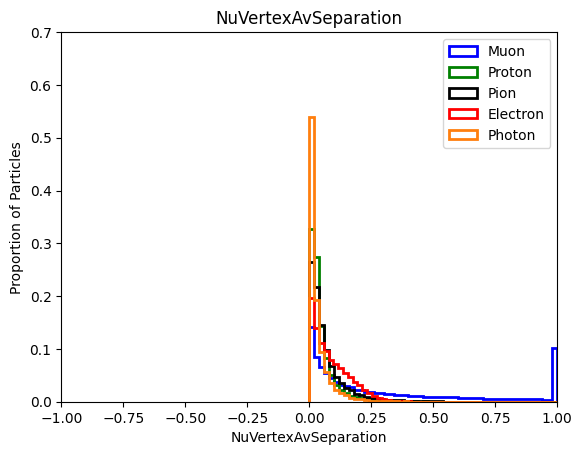

In [33]:
# Plot the nuVertexAvSeparation

nuVertexAvSeparationMin = -300
nuVertexAvSeparationMax = 300
    
for i in range(5) :

    thisNuVertexAvSeparation = nuVertexAvSeparation[particlePDG == i]
    
    thisNuVertexAvSeparation[thisNuVertexAvSeparation > nuVertexAvSeparationMax] = nuVertexAvSeparationMax
    thisNuVertexAvSeparation[thisNuVertexAvSeparation < nuVertexAvSeparationMin] = nuVertexAvSeparationMin
    thisNuVertexAvSeparation = thisNuVertexAvSeparation / nuVertexAvSeparationMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisNuVertexAvSeparation, bins=50, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-1.0, 1.0])
plt.ylim([0.0, 0.7])
plt.xlabel('NuVertexAvSeparation')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('NuVertexAvSeparation')

plt.show()

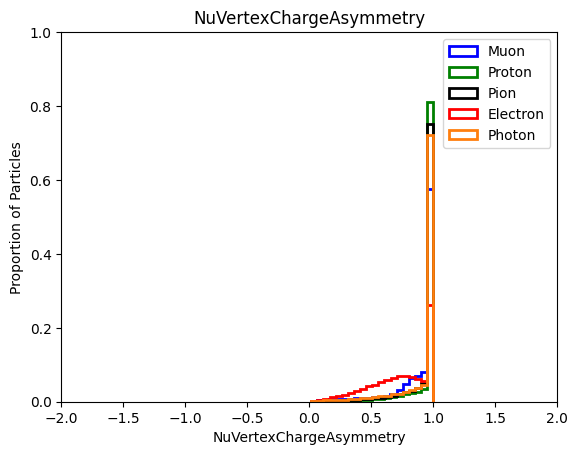

In [34]:
# Plot the nuVertexChargeAsymmetry

nuVertexChargeAsymmetryMin = -1.0
nuVertexChargeAsymmetryMax = 1.0
    
for i in range(5) :

    thisNuVertexChargeAsymmetry = nuVertexChargeAsymmetry[particlePDG == i]
    
    thisNuVertexChargeAsymmetry[thisNuVertexChargeAsymmetry > nuVertexChargeAsymmetryMax] = nuVertexChargeAsymmetryMax
    thisNuVertexChargeAsymmetry[thisNuVertexChargeAsymmetry < nuVertexChargeAsymmetryMin] = nuVertexChargeAsymmetryMin
    #thisNuVertexChargeAsymmetry = thisNuVertexChargeAsymmetry / nuVertexChargeAsymmetryMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisNuVertexChargeAsymmetry, bins=20, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('NuVertexChargeAsymmetry')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('NuVertexChargeAsymmetry')

plt.show()

In [ ]:
# Now the 'Isobel PhD' variables

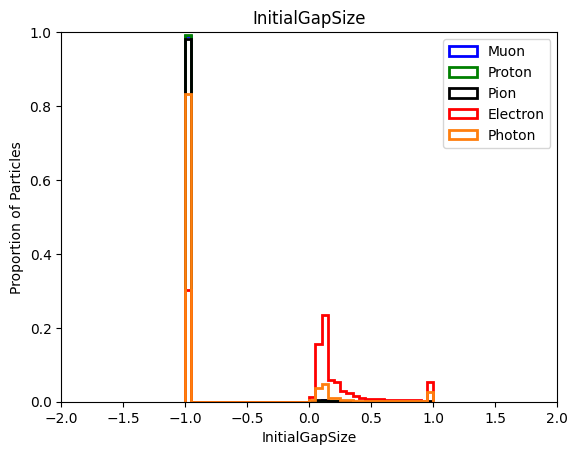

In [19]:
# Plot the initialGapSize

initialGapSizeMin = -4
initialGapSizeMax = 4
    
for i in range(5) :

    thisInitialGapSize = initialGapSize[particlePDG == i]
    
    thisInitialGapSize[thisInitialGapSize > initialGapSizeMax] = initialGapSizeMax
    thisInitialGapSize[thisInitialGapSize < -0.5] = initialGapSizeMin
    thisInitialGapSize = thisInitialGapSize / initialGapSizeMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisInitialGapSize, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('InitialGapSize')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('InitialGapSize')

plt.show()

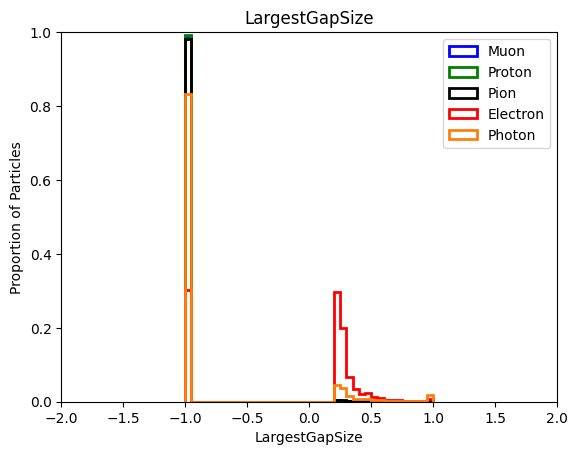

In [20]:
# Plot the largestGapSize

largestGapSizeMin = -2
largestGapSizeMax = 2
    
for i in range(5) :

    thisLargestGapSize = largestGapSize[particlePDG == i]
    
    thisLargestGapSize[thisLargestGapSize > largestGapSizeMax] = largestGapSizeMax
    thisLargestGapSize[thisLargestGapSize < -0.5] = largestGapSizeMin
    thisLargestGapSize = thisLargestGapSize / largestGapSizeMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisLargestGapSize, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('LargestGapSize')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('LargestGapSize')

plt.show()

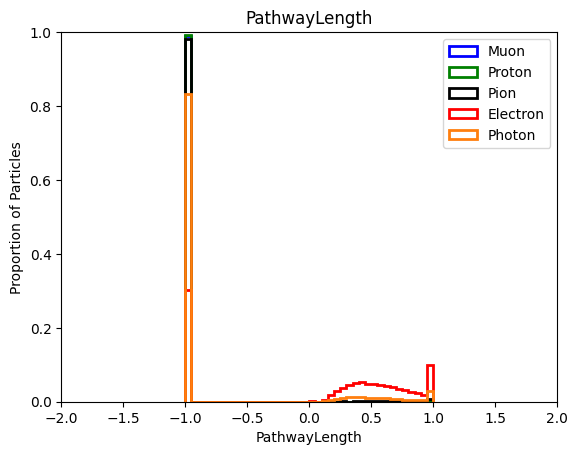

In [21]:
# Plot the pathwayLength

pathwayLengthMin = -30
pathwayLengthMax = 30
    
for i in range(5) :

    thisPathwayLength = pathwayLength[particlePDG == i]
    
    thisPathwayLength[thisPathwayLength > pathwayLengthMax] = pathwayLengthMax
    thisPathwayLength[thisPathwayLength < -0.5] = pathwayLengthMin
    thisPathwayLength = thisPathwayLength / pathwayLengthMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisPathwayLength, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('PathwayLength')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('PathwayLength')

plt.show()

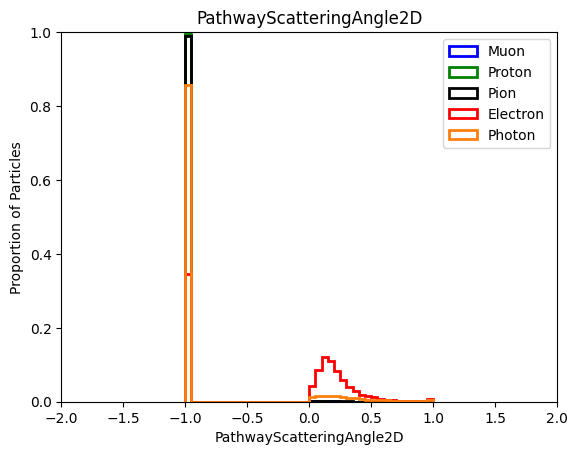

In [22]:
# Plot the pathwayScatteringAngle2D

pathwayScatteringAngle2DMin = -10
pathwayScatteringAngle2DMax = 10
    
for i in range(5) :

    thisPathwayScatteringAngle2D = pathwayScatteringAngle2D[particlePDG == i]
    
    thisPathwayScatteringAngle2D[thisPathwayScatteringAngle2D > pathwayScatteringAngle2DMax] = pathwayScatteringAngle2DMax
    thisPathwayScatteringAngle2D[thisPathwayScatteringAngle2D < -0.5] = pathwayScatteringAngle2DMin
    thisPathwayScatteringAngle2D = thisPathwayScatteringAngle2D / pathwayScatteringAngle2DMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisPathwayScatteringAngle2D, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('PathwayScatteringAngle2D')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('PathwayScatteringAngle2D')

plt.show()

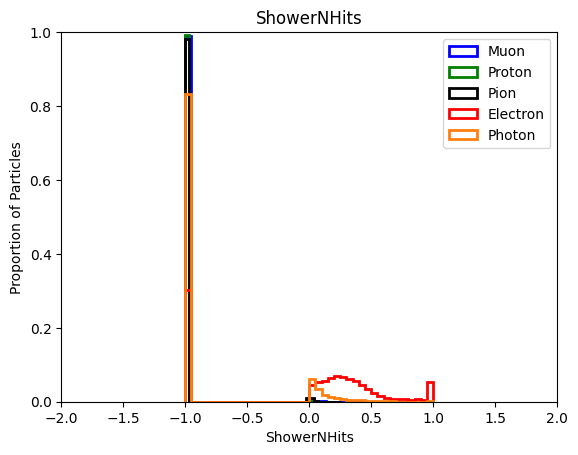

In [23]:
# Plot the showerNHits

showerNHitsMin = -2000
showerNHitsMax = 2000
    
for i in range(5) :

    thisShowerNHits = showerNHits[particlePDG == i]
    
    thisShowerNHits[thisShowerNHits > showerNHitsMax] = showerNHitsMax
    thisShowerNHits[thisShowerNHits < -0.5] = showerNHitsMin
    thisShowerNHits = thisShowerNHits / showerNHitsMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisShowerNHits, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('ShowerNHits')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('ShowerNHits')

plt.show()

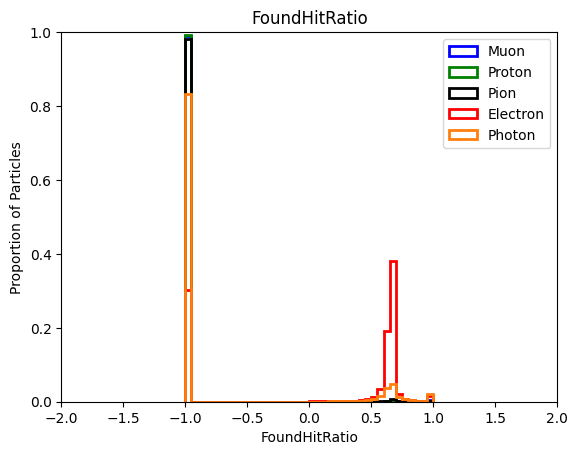

In [24]:
# Plot the foundHitRatio

foundHitRatioMin = -1.5
foundHitRatioMax = 1.5
    
for i in range(5) :

    thisFoundHitRatio = foundHitRatio[particlePDG == i]
    
    thisFoundHitRatio[thisFoundHitRatio > foundHitRatioMax] = foundHitRatioMax
    thisFoundHitRatio[thisFoundHitRatio < -0.5] = foundHitRatioMin
    thisFoundHitRatio = thisFoundHitRatio / foundHitRatioMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisFoundHitRatio, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('FoundHitRatio')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('FoundHitRatio')

plt.show()

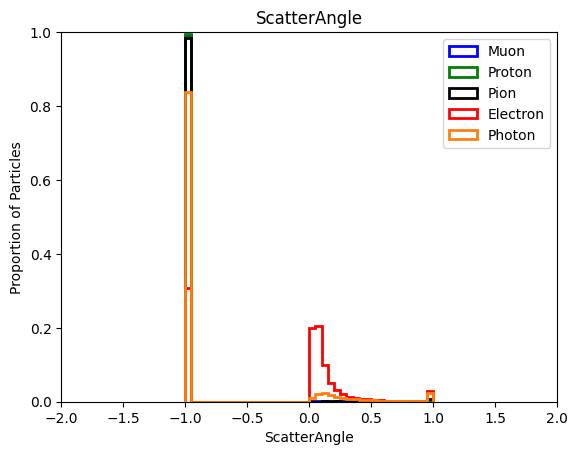

In [25]:
# Plot the scatterAngle

scatterAngleMin = -40
scatterAngleMax = 40
    
for i in range(5) :

    thisScatterAngle = scatterAngle[particlePDG == i]
    
    thisScatterAngle[thisScatterAngle > scatterAngleMax] = scatterAngleMax
    thisScatterAngle[thisScatterAngle < -0.5] = scatterAngleMin
    thisScatterAngle = thisScatterAngle / scatterAngleMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisScatterAngle, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('ScatterAngle')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('ScatterAngle')

plt.show()

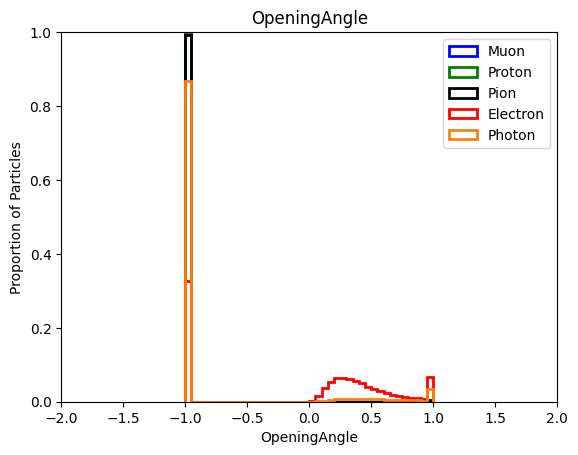

In [26]:
# Plot the openingAngle

openingAngleMin = -20
openingAngleMax = 20
    
for i in range(5) :

    thisOpeningAngle = openingAngle[particlePDG == i]
    
    thisOpeningAngle[thisOpeningAngle > openingAngleMax] = openingAngleMax
    thisOpeningAngle[thisOpeningAngle < -0.5] = openingAngleMin
    thisOpeningAngle = thisOpeningAngle / openingAngleMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisOpeningAngle, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('OpeningAngle')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('OpeningAngle')

plt.show()

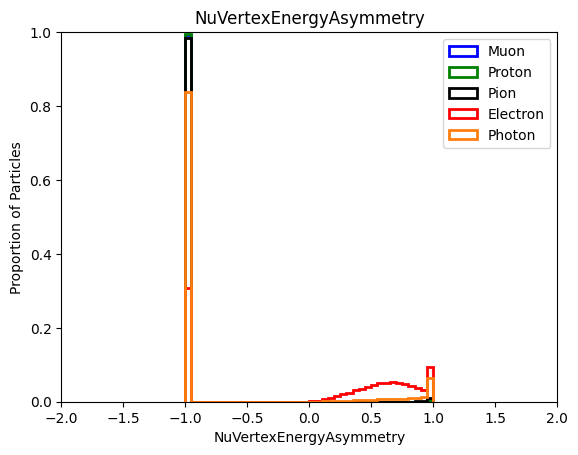

In [27]:
# Plot the nuVertexEnergyAsymmetry

nuVertexEnergyAsymmetryMin = -1
nuVertexEnergyAsymmetryMax = 1
    
for i in range(5) :

    thisNuVertexEnergyAsymmetry = nuVertexEnergyAsymmetry[particlePDG == i]
    
    thisNuVertexEnergyAsymmetry[thisNuVertexEnergyAsymmetry > nuVertexEnergyAsymmetryMax] = nuVertexEnergyAsymmetryMax
    thisNuVertexEnergyAsymmetry[thisNuVertexEnergyAsymmetry < -0.01] = nuVertexEnergyAsymmetryMin
    thisNuVertexEnergyAsymmetry = thisNuVertexEnergyAsymmetry / nuVertexEnergyAsymmetryMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisNuVertexEnergyAsymmetry, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('NuVertexEnergyAsymmetry')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('NuVertexEnergyAsymmetry')

plt.show()

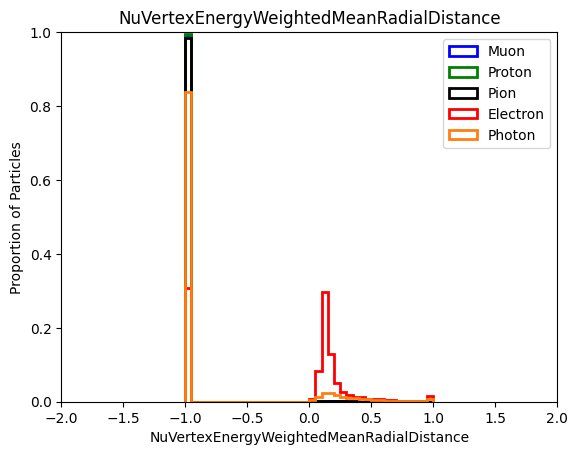

In [28]:
# Plot the nuVertexEnergyWeightedMeanRadialDistance

nuVertexEnergyWeightedMeanRadialDistanceMin = -20
nuVertexEnergyWeightedMeanRadialDistanceMax = 20
    
for i in range(5) :

    thisNuVertexEnergyWeightedMeanRadialDistance = nuVertexEnergyWeightedMeanRadialDistance[particlePDG == i]
    
    thisNuVertexEnergyWeightedMeanRadialDistance[thisNuVertexEnergyWeightedMeanRadialDistance > nuVertexEnergyWeightedMeanRadialDistanceMax] = nuVertexEnergyWeightedMeanRadialDistanceMax
    thisNuVertexEnergyWeightedMeanRadialDistance[thisNuVertexEnergyWeightedMeanRadialDistance < -0.01] = nuVertexEnergyWeightedMeanRadialDistanceMin
    thisNuVertexEnergyWeightedMeanRadialDistance = thisNuVertexEnergyWeightedMeanRadialDistance / nuVertexEnergyWeightedMeanRadialDistanceMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisNuVertexEnergyWeightedMeanRadialDistance, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('NuVertexEnergyWeightedMeanRadialDistance')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('NuVertexEnergyWeightedMeanRadialDistance')

plt.show()

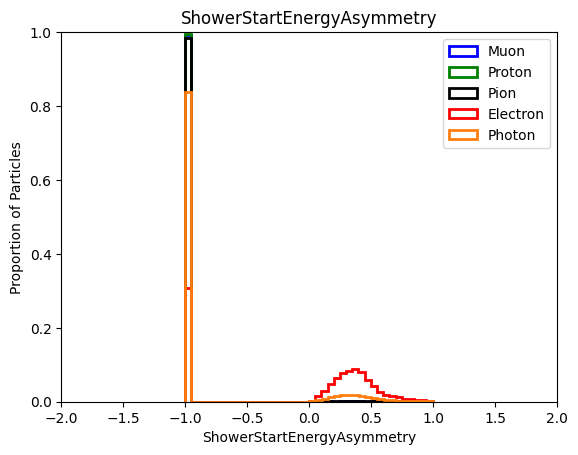

In [35]:
# Plot the showerStartEnergyAsymmetry

showerStartEnergyAsymmetryMin = -1
showerStartEnergyAsymmetryMax = 1
    
for i in range(5) :

    thisShowerStartEnergyAsymmetry = showerStartEnergyAsymmetry[particlePDG == i]
    
    thisShowerStartEnergyAsymmetry[thisShowerStartEnergyAsymmetry > showerStartEnergyAsymmetryMax] = showerStartEnergyAsymmetryMax
    thisShowerStartEnergyAsymmetry[thisShowerStartEnergyAsymmetry < -0.01] = showerStartEnergyAsymmetryMin
    thisShowerStartEnergyAsymmetry = thisShowerStartEnergyAsymmetry / showerStartEnergyAsymmetryMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisShowerStartEnergyAsymmetry, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('ShowerStartEnergyAsymmetry')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('ShowerStartEnergyAsymmetry')

plt.show()

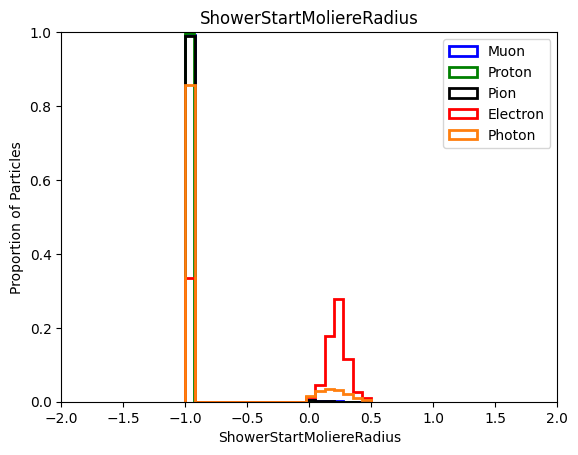

In [30]:
# Plot the showerStartMoliereRadius

showerStartMoliereRadiusMin = -20
showerStartMoliereRadiusMax = 20
    
for i in range(5) :

    thisShowerStartMoliereRadius = showerStartMoliereRadius[particlePDG == i]
    
    thisShowerStartMoliereRadius[thisShowerStartMoliereRadius > showerStartMoliereRadiusMax] = showerStartMoliereRadiusMax
    thisShowerStartMoliereRadius[thisShowerStartMoliereRadius < -0.5] = showerStartMoliereRadiusMin
    thisShowerStartMoliereRadius = thisShowerStartMoliereRadius / showerStartMoliereRadiusMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisShowerStartMoliereRadius, bins=20, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2])
plt.ylim([0.0, 1.0])
plt.xlabel('ShowerStartMoliereRadius')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('ShowerStartMoliereRadius')

plt.show()

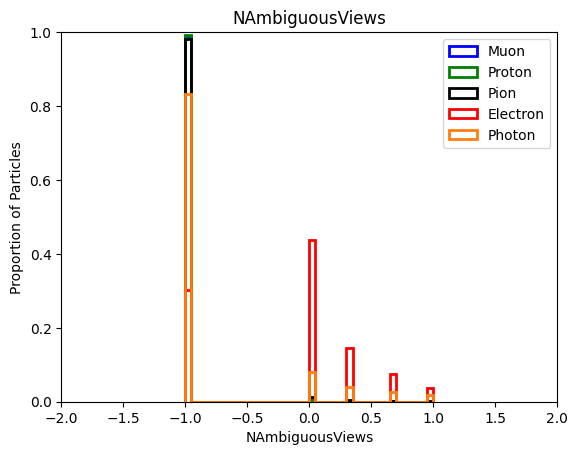

In [31]:
# Plot the nAmbiguousViews

nAmbiguousViewsMin = -3
nAmbiguousViewsMax = 3
    
for i in range(5) :

    thisNAmbiguousViews = nAmbiguousViews[particlePDG == i]
    
    thisNAmbiguousViews[thisNAmbiguousViews > nAmbiguousViewsMax] = nAmbiguousViewsMax
    thisNAmbiguousViews[thisNAmbiguousViews < -0.5] = nAmbiguousViewsMin
    thisNAmbiguousViews = thisNAmbiguousViews / nAmbiguousViewsMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisNAmbiguousViews, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('NAmbiguousViews')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('NAmbiguousViews')

plt.show()

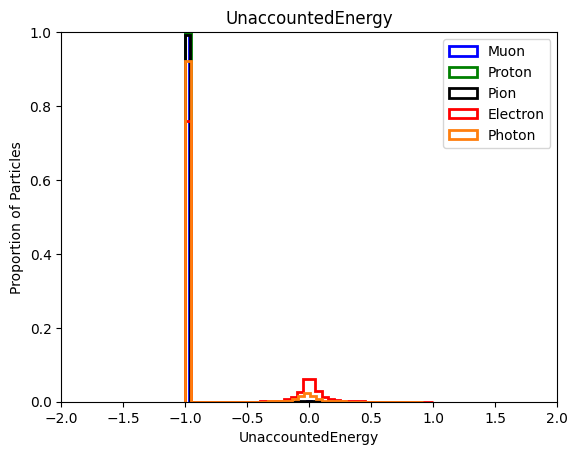

In [32]:
# Plot the unaccountedEnergy

unaccountedEnergyMin = -10
unaccountedEnergyMax = 10
    
for i in range(5) :

    thisUnaccountedEnergy = unaccountedEnergy[particlePDG == i]
    
    thisUnaccountedEnergy[thisUnaccountedEnergy > unaccountedEnergyMax] = unaccountedEnergyMax
    thisUnaccountedEnergy[thisUnaccountedEnergy < unaccountedEnergyMin] = unaccountedEnergyMin
    thisUnaccountedEnergy = thisUnaccountedEnergy / unaccountedEnergyMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisUnaccountedEnergy, bins=40, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 2.0])
plt.ylim([0.0, 1.0])
plt.xlabel('UnaccountedEnergy')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('UnaccountedEnergy')

plt.show()